# **MÓDULO 14 - Exercício**
# Pré Processamento dos Dados - A primeira etapa Pré Modelagem

Para nossa atividade usaremos uma base de churn também, porém essa base não diz respeito a serviços bancários e sim serviços de internet, telefone e tv - Telecomunicação.

Vamos realizar aqui as etapas de limpeza e tratamento de dados vistos durante a aula, porém aplicados a essa base nova.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CHURN_CREDIT_MOD08.csv", delimiter=';')

df.head(10)

C:\Users\marcelo\AppData\Local\Temp\ipykernel_19192\1802252872.py:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("CHURN_CREDIT_MOD08.csv", delimiter=';')


,CustomerId,Sobrenome,Credit_Score,Pais,Genero,Idade,Tempo_Credito,Balance,Qtd_Produtos,Possui_Cartao,Membro_Ativo,Salario_Anual,Churn
0,15813451,Fleetwood-Smith,677,Spain,Male,18.0,5,134796.87,2,1.0,0.0,114858.9,0.0
1,15641688,Collier,644,Spain,Female,18.0,7,0.00,1,0.0,1.0,74564.41,0.0
2,15757821,Burgess,641,Spain,Male,18.0,1,0.00,2,0.0,1.0,41542.95,0.0
3,15673180,Onyekaozulu,826,Spain,Male,18.0,2,0.00,2,0.0,1.0,16245.25,0.0
4,15664543,Tuan,774,Spain,Female,18.0,1,185891.54,1,1.0,0.0,175072.41,0.0
5,15673180,Onyekaozulu,688,Spain,Female,18.0,2,0.00,2,1.0,0.0,98349.13,0.0
6,15641688,Collier,803,Spain,Male,18.0,6,0.00,1,0.0,0.0,59645.24,1.0
7,15672940,Yevseyev,578,Spain,Female,18.0,8,71843.15,2,0.0,1.0,112649.22,0.0
8,15694192,Nwankwo,598,Spain,Male,18.0,6,0.00,2,0.0,1.0,173783.38,0.0
9,15585867,Iroawuchi,624,Spain,Female,18.0,6,0.00,2,0.0,1.0,117038.96,0.0


Legenda dos dados:

*   **CustomerID** : Esse é o ID único de cada cliente nosso da rede de produtos de telecomunicação.

*   **Genero** : O genero dos nossos clientes.

*   **Idoso** : Se nosso cliente tem acima de 60 anos ou não. (Sim = 1 | Não = 0)

*   **Casado** : Se nosso cliente é casado ou não.

*   **Dependents** : Se cliente tem dependentes.

*   **Tempo_como_Cliente** : Tempo em meses que nosso cliente está com a nossa empresa.

*   **PhoneService** : Se ele contratou serviço telefônico com a nossa empresa.

*   **Servico_Internet** : Qual o tipo de serviço de internet contratado.

*   **Servico_Seguranca** : Se ele contratou serviço de segurança com a nossa empresa.

*   **Suporte_Tecnico** : Se já acionou o suporte técnico.

*   **StreamingTV** : Se ele contratou serviço de streaming para TV.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **PaymentMethod** : Forma de Pagamento.

*   **Pagamento_Mensal** : Quanto o cliente pagava mensalmente.

*   **Total_Pago** : Total já pago pelo cliente para nossa companhia.

*   **Churn** : Nossa coluna mais importante, se nosso cliente nos abandonou ou não.




# 1 - Carregue a base, verifique se os tipos de dados estão de acordo com cada coluna e caso não estejam realize a transformação dos tipos de dados.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   CustomerId     100000 non-null  int64  
 1   Sobrenome      100000 non-null  object 
 2   Credit_Score   100000 non-null  int64  
 3   Pais           100000 non-null  object 
 4   Genero         99990 non-null   object 
 5   Idade          99794 non-null   float64
 6   Tempo_Credito  100000 non-null  int64  
 7   Balance        100000 non-null  float64
 8   Qtd_Produtos   100000 non-null  int64  
 9   Possui_Cartao  100000 non-null  float64
 10  Membro_Ativo   100000 non-null  float64
 11  Salario_Anual  100000 non-null  object 
 12  Churn          99911 non-null   float64
dtypes: float64(5), int64(4), object(4)
memory usage: 9.9+ MB


In [126]:
df.isnull().values.any()

np.True_

# 2 - Esse exercício faremos por etapas:
A) Verifique se temos colunas com dados faltantes e traga a % dos dados faltantes por coluna.

In [127]:
df.isnull().sum()

customerID               0
Genero                  12
Idoso                    0
Casado                   0
Dependents               0
Tempo_como_Cliente       0
PhoneService          1482
Servico_Internet         0
Servico_Seguranca        0
Suporte_Tecnico          0
StreamingTV              0
Tipo_Contrato            0
PaymentMethod            0
Pagamento_Mensal       325
Total_Pago               0
Churn                    5
dtype: int64

In [128]:
#Porcentegem de números faltantes
(df.isnull().sum() / len(df)) * 100

customerID             0.00
Genero                 0.48
Idoso                  0.00
Casado                 0.00
Dependents             0.00
Tempo_como_Cliente     0.00
PhoneService          59.28
Servico_Internet       0.00
Servico_Seguranca      0.00
Suporte_Tecnico        0.00
StreamingTV            0.00
Tipo_Contrato          0.00
PaymentMethod          0.00
Pagamento_Mensal      13.00
Total_Pago             0.00
Churn                  0.20
dtype: float64

**Na saída acima, vemos que as duas colunas Phone_Service e Pagamento_Mensal, aprecentam uma porcentagem significativa de números faltantes o que pode impactar na análise.**

B) Exclua nessa etapa as linhas das colunas com dados faltantes que você analisar que esse método é o ideal. Justifique o motivo de estar excluindo essas linhas.

In [6]:
df[df['Genero'].isnull()]

,CustomerId,Sobrenome,Credit_Score,Pais,Genero,Idade,Tempo_Credito,Balance,Qtd_Produtos,Possui_Cartao,Membro_Ativo,Salario_Anual,Churn
61074,15601008,Y?an,667,France,NaN,33.0,3,0.00,2,1.0,1.0,171757.57,0.0
61075,15757895,Ritchie,642,France,NaN,33.0,4,150507.21,1,1.0,1.0,125439.73,0.0
61076,15806983,Moss,646,France,NaN,33.0,3,137148.68,1,1.0,0.0,92381.01,0.0
61077,15761340,Bullen,593,France,NaN,33.0,4,0.00,2,1.0,1.0,99828.45,0.0
61078,15790594,Nnaife,653,France,NaN,33.0,6,0.00,2,1.0,0.0,113483.96,0.0
61079,15679024,Hsia,585,France,NaN,33.0,2,97565.74,1,0.0,0.0,114775.53,0.0
61080,15751553,Bellucci,758,France,NaN,33.0,9,119782.77,1,1.0,0.0,132418.73,0.0
61081,15592578,Ch'ien,679,France,NaN,33.0,7,107499.24,1,1.0,0.0,126715.85,0.0
61082,15592714,Tsao,748,France,NaN,33.0,6,0.00,2,1.0,1.0,147557.71,0.0
61083,15578788,Ch'ien,516,France,NaN,33.0,3,0.00,1,1.0,1.0,137835.82,0.0


In [8]:
df.dropna(subset=['Genero'], inplace=True)

In [9]:
df['Genero'].isnull().sum()

np.int64(0)

**Neste caso, optamos por excluir a linhas da coluna Genero uma vez que não é um dado relevante para a análise e não interfere no resultado final.**

In [10]:
df[df['PhoneService'].isnull()]

KeyError: 'PhoneService'

In [135]:
df.dropna(subset=['PhoneService'], inplace=True)

In [11]:
df['PhoneService'].isnull().sum()

KeyError: 'PhoneService'

**Nesta analisem, também decidimos excluir as linhas contendo dados nulos da coluna PhoneService. Pois mais mais da metade dos dados eram nulos ou seja, 59% o que poderia enviesar a analise final.**

C) Nessa etapa substitua pela média, mediana ou moda as linhas das colunas com valores faltantes que você analisou e entendeu que esse era o melhor método. Não se esqueça de justificar sua escolha.

**Dica variáveis numéricas:** Não se esqueça de verificar a distrbuição dos dados, média e mediana.

**Dica variáveis categóricas:** Caso precise substituir uma variável categórica utilize um gráfico de barras para verificar a que mais aparece e utilizar ela na substituição.
Ou você pode optar por excluir a coluna, mas justifique sua escolha.

Caso opte por substituir você pode utilizar a função fillna:
df['SUACOLUNA'].fillna("VALOR QUE SUBSTITUIRA O NULO", inplace=True)
Ela funcionará como a replace.

In [12]:
df['Pagamento_Mensal'] = df['Pagamento_Mensal'].fillna(df['Pagamento_Mensal'].median())

KeyError: 'Pagamento_Mensal'

**Analisando a coluna Pagamento_Mensal, verificamos que valores financeiros contumam ter outliers. Sendo assim, decidimos substiuir os valores faltantes pela mediana , que é a mais indicada para esta base.**

In [138]:
df['Pagamento_Mensal'].head()

0     29.85
1     56.95
2     53.85
3     70.55
16    70.55
Name: Pagamento_Mensal, dtype: float64

**Aqui vemos o resultado das primeiras linhas já preenchidas.**

In [13]:
# Analizando a coluna Pagamento_Mensal e verificando quantidade de valores nulos 
df['Pagamento_Mensal'].isnull().sum()

KeyError: 'Pagamento_Mensal'

In [14]:
#Analisando a mais a fundo a distribuição dos dados.
df['Pagamento_Mensal'].mean()

KeyError: 'Pagamento_Mensal'

In [141]:
# Calculando a mediana da coluna Pagamento_Mensal
df['Pagamento_Mensal'].median()

70.55

In [76]:
# Excluindo linhas com valores nulos na coluna Churn
df = df.dropna(subset=['Churn'])

**Por conter poucos valores nulos, também decidimos exluí-los na coluna  Churn**

# Plotando o gráfico Histograma

In [17]:
# Plotando um histograma dos Pagamento Mensal para analisarmos a distribuição dos dados
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('darkgrid')

plt.figure(figsize=(10, 6))
ax = sns.histplot(data=df, x='Pagamento_Mensal', bins=20, kde=True, color='skyblue')

# Adicionando valores
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            int(height),
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.title('Histograma da Coluna de Pagamento Mensal')
plt.xlabel('Pagamento_Mensal')
plt.ylabel('Contagem')
plt.show()

ValueError: Could not interpret value `Pagamento_Mensal` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

**No gráfico acima, vemos a distrubuição de valores de pagamento, onde podemos ver quantos clientes estão em cada faixa de valor. Na primeira barra e na barra central, vemos uma forte concentração de valores altos, comparada com as outras barras que apresentam valores mais distribuídos. Ou seja, não é uma distribuiçao simétrica. Dois perfis de clientes (baixo custo vs médio/alto custo).**

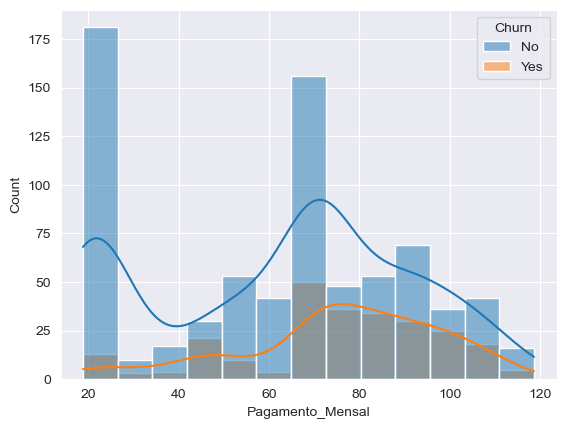

In [145]:
sns.histplot(data=df, x='Pagamento_Mensal', hue='Churn', kde=True)
plt.show()

**Neste Histograma, podemos ver a distribuição em relção ao Churn. Neste caso, vemos uma distribuição assimétrica com concentração significativa em valores baixos e um segundo grupo relevante em faixas mais altas de pagamento. Isso indica a existência de diferentes perfis de clientes. A presença de múltiplos picos sugere segmentação natural da base. Uma taxa de Churn equilibrada**.

# Plotando o gráfico Boxplot 

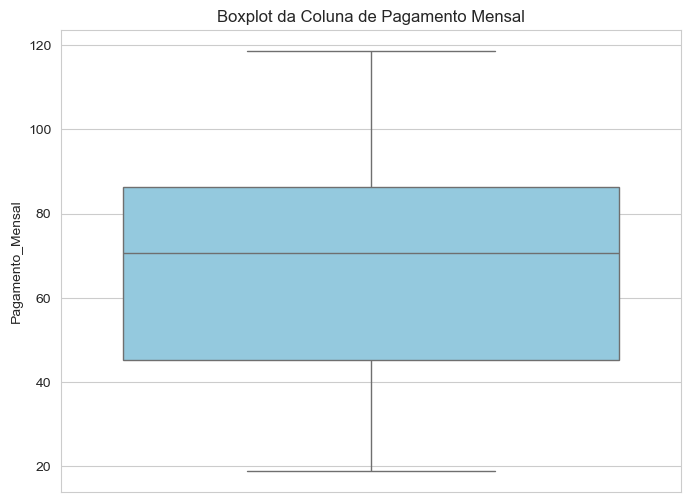

In [146]:
# Plota o boxplot da coluna de Pagamento Mensal
sns.set_style('whitegrid')

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='Pagamento_Mensal', color='skyblue')
plt.title('Boxplot da Coluna de Pagamento Mensal')
plt.ylabel('Pagamento_Mensal')
plt.show()

Analisando o gráfico bloxplot acima, vemos a linha central (mediana) representando o valor típico do Pagamento Mensal, na faixa dos 70 a 80. Vemos também que alguns cliente pagam mais que o padrão.

In [147]:
#porcentagem de clientes que cancelaram

In [148]:
df['Churn'].value_counts()

Churn
No     753
Yes    253
Name: count, dtype: int64

In [149]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     74.850895
Yes    25.149105
Name: proportion, dtype: float64

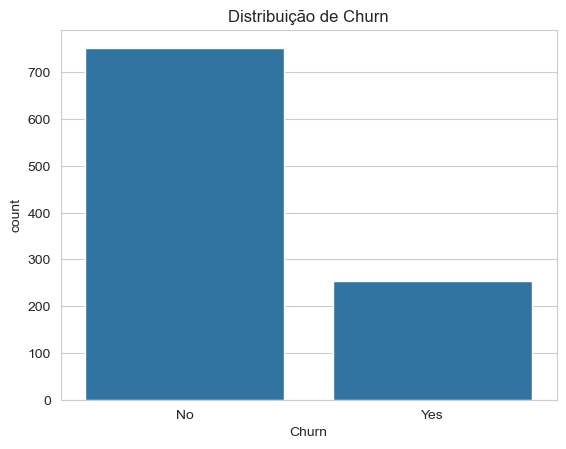

In [150]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Churn')
plt.title('Distribuição de Churn')
plt.show()

**Minha conclusão: Ao analisar o gráfico de distribuição de churn, observa-se que aproximadamente 74% dos clientes permanecem na base, enquanto cerca de 25% cancelaram o serviço. Isso indica que a taxa de churn está em torno de 25%, o que pode ser considerado um valor relevante.**

**Implicações para o negócio: Esse cenário sugere a existência de uma evasão significativa de clientes. Entre os possíveis fatores, destacam-se: problemas relacionados a preço, qualidade do serviço ou estratégias insuficientes de retenção.**

# 3 - Verifique se encontramos valores digitados incorretamente, ou com letras maiusculas ou minusculas, ou até mesmo mesmos valores porém escritos de forma dirente e corrija.

In [151]:
# Normalizando / Padronizando a coluna Genero

In [153]:
df['Genero'] = df['Genero'].replace({
    'm': 'Male',
    'F': 'Female',
    'masculino': 'Male',
    'f': 'female',
    'feminino': 'Female',
    'M': 'Male'
    })

In [156]:
df['Genero'] = df['Genero'].str.capitalize()

In [157]:
df['Genero'].unique()

array(['Female', 'Male'], dtype=object)

**Nesta etapa, padronizamos os nomes dos valores contidos nas linhas da coluna Genero.**

# [EXTRA] 4 - Caso deseje, para manter um padrão na sua base, renomeie as colunas ou deixando em português, ou inglês.

In [15]:
# Alterando e padronizando as colunas do DataFrame.
df.rename(columns={
    "Tempo_como_Cliente": "CustomerTime",
    "Servico_Internet": "InternetService",
    "Suporte_Tecnico": "TechinicalSupport",
    "Servico_Seguranca": "SecurityService",
    "Tipo_Contrato": "ContractType",
    "Pagamento_Mensal": "MonthlyPayment",
    "Genero": "Gender", "Idoso": "Senior",
    "customerID": "CustomerID",
    "Casado": "Married", "Total_Pago": "TotalPaid"
}, inplace=True)

In [16]:
df.head()

,CustomerId,Sobrenome,Credit_Score,Pais,Gender,Idade,Tempo_Credito,Balance,Qtd_Produtos,Possui_Cartao,Membro_Ativo,Salario_Anual,Churn
0,15813451,Fleetwood-Smith,677,Spain,Male,18.0,5,134796.87,2,1.0,0.0,114858.9,0.0
1,15641688,Collier,644,Spain,Female,18.0,7,0.00,1,0.0,1.0,74564.41,0.0
2,15757821,Burgess,641,Spain,Male,18.0,1,0.00,2,0.0,1.0,41542.95,0.0
3,15673180,Onyekaozulu,826,Spain,Male,18.0,2,0.00,2,0.0,1.0,16245.25,0.0
4,15664543,Tuan,774,Spain,Female,18.0,1,185891.54,1,1.0,0.0,175072.41,0.0


**Nesta etapa, padronizamos os nomes das colunas, para o inglês e, excluimos o underline entre os nomes.** 